In [29]:
# in this file i come with much prep and studied about the data itself


In [19]:
import pandas as pd 
df= pd.read_csv("Loan_default_1500.csv")
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,26394,2019,cf,Joint,pre,type3,p1,l1,nopc,nob/c,...,CIB,533,EXP,35-44,to_inst,99.369748,North,direct,0,44.0
1505,26395,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,EQUI,834,EXP,55-64,to_inst,NaN,south,direct,1,NaN
1506,26396,2019,cf,Male,nopre,type2,p4,l1,nopc,b/c,...,EXP,624,CIB,45-54,to_inst,73.734177,North,direct,1,26.0
1507,26397,2019,cf,Male,nopre,type1,p3,l1,nopc,nob/c,...,EXP,840,EXP,35-44,to_inst,72.606383,North,direct,0,38.0


In [20]:
df_raw=df.copy()
drop_cols = [
    "ID",# just an ID, no use for prediction
    "year",# year doesn't affect default directly
    "open_credit",# same value for all rows → useless
    "Region",# not strongly linked to loan risk
    "Security_Type",# already covered by other columns
    "co-applicant_credit_type",# messy and not very useful
    "submission_of_application", # process info, not financial risk
    "age", # as it is in range so its of no use 
]
df_model=df_raw.drop(columns = drop_cols,errors = "ignore").copy()

In [21]:
df_model.head()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,...,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,LTV,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nob/c,116500,NaN,NaN,...,sb,pr,home,1U,1740.0,EXP,758,98.728814,1,45.0
1,cf,Male,nopre,type2,p1,l1,b/c,206500,NaN,NaN,...,sb,pr,home,1U,4980.0,EQUI,552,NaN,1,NaN
2,cf,Male,pre,type1,p1,l1,nob/c,406500,4.56,0.2000,...,sb,pr,home,1U,9480.0,EXP,834,80.019685,0,46.0
3,cf,Male,nopre,type1,p4,l1,nob/c,456500,4.25,0.6810,...,sb,pr,home,1U,11880.0,EXP,587,69.376900,0,42.0
4,cf,Joint,pre,type1,p1,l1,nob/c,696500,4.00,0.3042,...,sb,pr,home,1U,10440.0,CRIF,602,91.886544,0,39.0


In [22]:
# now lets perform some data cleaning and pre-processing 

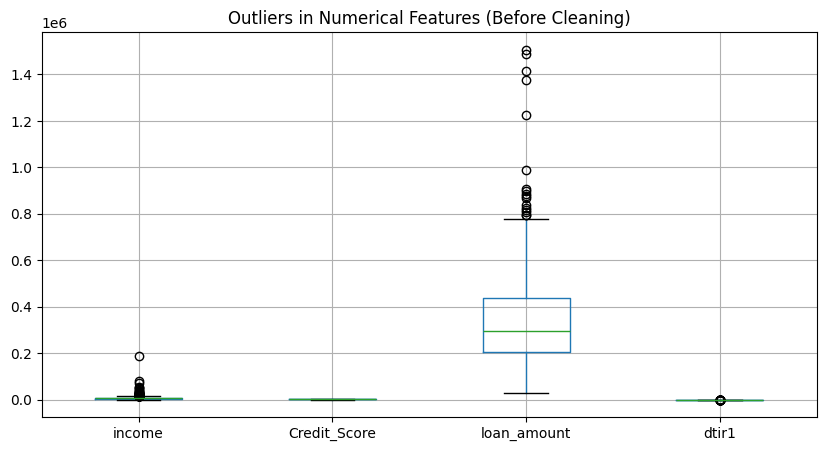

In [57]:
plt.figure(figsize=(10,5))

df_model[['income', 'Credit_Score', 'loan_amount', 'dtir1']].boxplot()

plt.title("Outliers in Numerical Features (Before Cleaning)")
plt.show()

In [24]:
df_model= df_model.drop_duplicates()
# rather than performing imputation seperately on each column i do imputation for numeric columns at once with median and mode for catagorical data 
df_model["income"] = df_model["income"].fillna(df_model["income"].median())


In [25]:
#moment of truth lets check if my shortcut worked welll
df_model.isnull().sum()

loan_limit                 38
Gender                      0
approv_in_adv               8
loan_type                   0
loan_purpose                0
Credit_Worthiness           0
business_or_commercial      0
loan_amount                 0
rate_of_interest          371
Interest_rate_spread      375
Upfront_charges           413
term                        1
Neg_ammortization           0
interest_only               0
lump_sum_payment            0
property_value            150
construction_type           0
occupancy_type              0
Secured_by                  0
total_units                 0
income                      0
credit_type                 0
Credit_Score                0
LTV                       150
Status                      0
dtir1                     250
dtype: int64

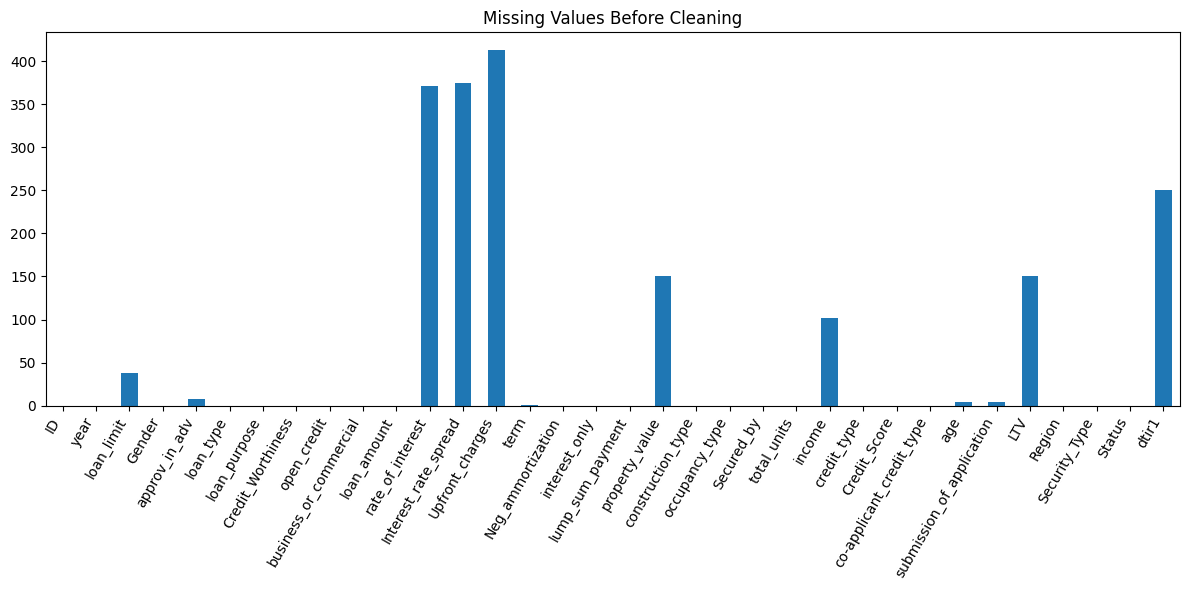

In [26]:
import matplotlib.pyplot as plt

missing = df_raw.isnull().sum()

plt.figure(figsize=(12,6))
missing.plot(kind='bar')
plt.title("Missing Values Before Cleaning")
plt.xticks(rotation=60, ha='right')   # fix overlap
plt.tight_layout()
plt.show()

In [39]:

df_model["dtir1"] = df_model["dtir1"].fillna(df_model["dtir1"].median())
df_model["income"] = df_model["income"].fillna(df_model["income"].median())
df_model["property_value"] = df_model["property_value"].fillna(df_model["property_value"].median())
df_model["LTV"] = df_model["LTV"].fillna(df_model["LTV"].median())
df_model["loan_limit"] = df_model["loan_limit"].fillna(df_model["loan_limit"].mode()[0])
df_model["rate_of_interest"] = df_model["rate_of_interest"].fillna(df_model["rate_of_interest"].median())
df_model["Upfront_charges"] = df_model["Upfront_charges"].fillna(df_model["Upfront_charges"].median())
df_model["term"] = df_model["term"].fillna(df_model["term"].mode()[0])
df_model["Interest_rate_spread"] = df_model.groupby("loan_type")["Interest_rate_spread"]\
    .transform(lambda x: x.fillna(x.median()))
df_model['approv_in_adv'].mode()
df_model['approv_in_adv'] = df['approv_in_adv'].fillna(df['approv_in_adv'].mode()[0])
cols = ['income', 'loan_amount']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)
print("imputation successfull")
print("Outliers treated successfully")

imputation successfull
Outliers treated successfully


In [40]:
df_model.isnull().sum()

loan_limit                0
Gender                    0
approv_in_adv             0
loan_type                 0
loan_purpose              0
Credit_Worthiness         0
business_or_commercial    0
loan_amount               0
rate_of_interest          0
Interest_rate_spread      0
Upfront_charges           0
term                      0
Neg_ammortization         0
interest_only             0
lump_sum_payment          0
property_value            0
construction_type         0
occupancy_type            0
Secured_by                0
total_units               0
income                    0
credit_type               0
Credit_Score              0
LTV                       0
Status                    0
dtir1                     0
dtype: int64

In [41]:
df_model= pd.read_csv("cleaned_dataset2.csv")
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,26394,2019,cf,Joint,pre,type3,p1,l1,nopc,nob/c,...,CIB,533,EXP,35-44,to_inst,99.369748,North,direct,0,44.0
1505,26395,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,EQUI,834,EXP,55-64,to_inst,NaN,south,direct,1,NaN
1506,26396,2019,cf,Male,nopre,type2,p4,l1,nopc,b/c,...,EXP,624,CIB,45-54,to_inst,73.734177,North,direct,1,26.0
1507,26397,2019,cf,Male,nopre,type1,p3,l1,nopc,nob/c,...,EXP,840,EXP,35-44,to_inst,72.606383,North,direct,0,38.0


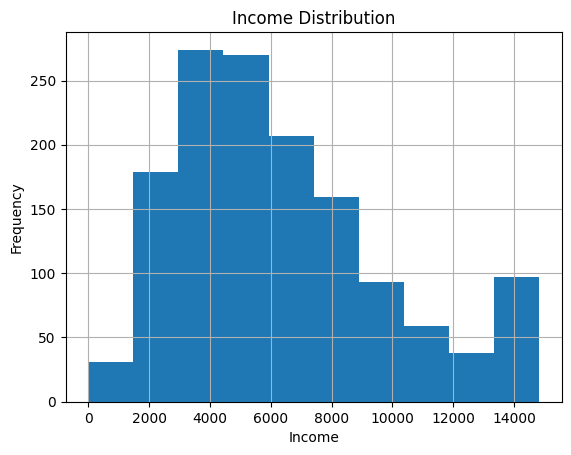

In [43]:
plt.figure()
df['income'].hist()
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

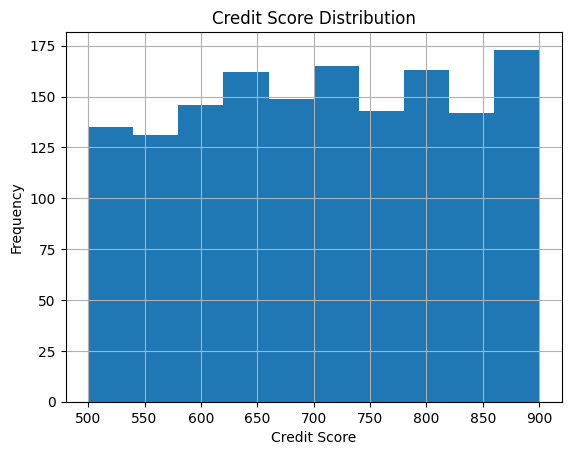

In [44]:
plt.figure()
df['Credit_Score'].hist()
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

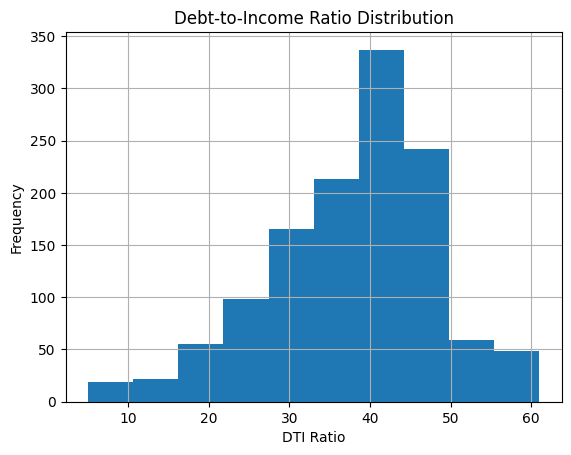

In [45]:
plt.figure()
df['dtir1'].hist()
plt.title("Debt-to-Income Ratio Distribution")
plt.xlabel("DTI Ratio")
plt.ylabel("Frequency")
plt.show()

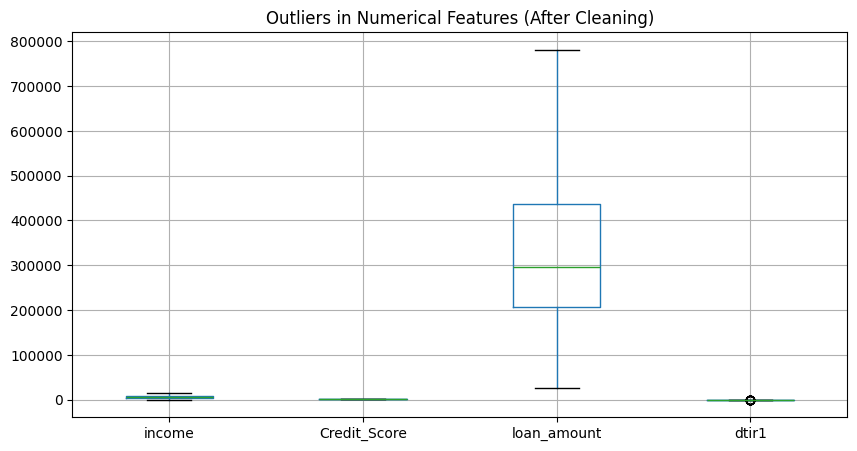

In [46]:
plt.figure(figsize=(10,5))
df[['income', 'Credit_Score', 'loan_amount', 'dtir1']].boxplot()
plt.title("Outliers in Numerical Features (After Cleaning)")
plt.show()

In [47]:
# adding a column loan stress to know that how much the loan effects the applicant on the basis of their income 
df_model["loan_to_income"]= (df_model["loan_amount"] / (df_model["income"] + 1)).round(3)
df_model["loan_to_income"] 

0       66.916
1       41.458
2       42.875
3       38.423
4       66.708
         ...  
1504    40.214
1505    72.751
1506    49.765
1507    45.485
1508    43.249
Name: loan_to_income, Length: 1509, dtype: float64

In [48]:
#in the scenario wehre ddefault happens we can check beforehand that the collateral can help bank to recover or not 
df_model["loan_to_collateral"]= (df_model["loan_amount"] / (df_model["property_value"] + 1)).round(3)
df_model["loan_to_collateral"]

0       0.987
1       0.494
2       0.800
3       0.694
4       0.919
        ...  
1504    0.994
1505    0.470
1506    0.737
1507    0.726
1508    0.992
Name: loan_to_collateral, Length: 1509, dtype: float64

In [49]:
# we also verify if the interest in a loan amount isn't burdening the applicant so that we can reduce the risk 
df_model["interest_burden"]= (df_model["rate_of_interest"] * df_model["loan_amount"])
df_model["interest_burden"]

0        464835.0
1        823935.0
2       1853640.0
3       1940125.0
4       2786000.0
          ...    
1504    1034687.5
1505     784035.0
1506     464835.0
1507     544635.0
1508     573625.0
Name: interest_burden, Length: 1509, dtype: float64

In [50]:
#also looking if the upfront charges("charges while applying for loan")are not a burden to applicant 
df_model["total_cost_proxy"] = df_model["Upfront_charges"] + df_model["interest_burden"]
df_model["total_cost_proxy"]

0        467526.13
1        826626.13
2       1854235.00
3       1942816.13
4       2786000.00
           ...    
1504    1036987.50
1505     786726.13
1506     467526.13
1507     547745.38
1508     577041.77
Name: total_cost_proxy, Length: 1509, dtype: float64

In [51]:
#risk score that includes credit and dtir so that we can give model idea of credit risk in one column itself
df_model["risk_score"] = (
    (700 - df_model["Credit_Score"]) * 0.6 + df_model["dtir1"] * 0.4)
#the threshold is based on as better credit score shows that applicant has higher chances of repaying the loan and woiuld be able to manage the debt 

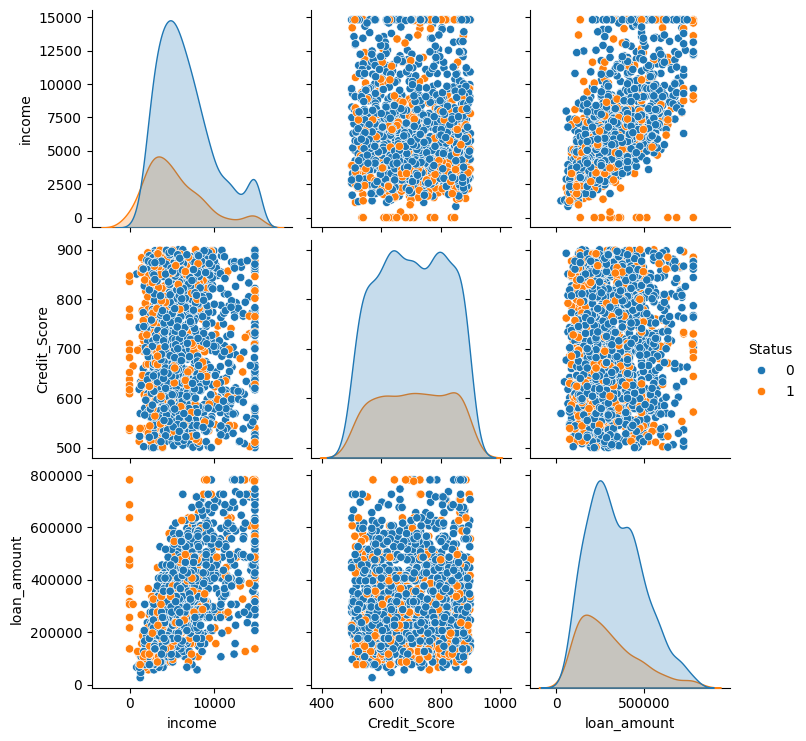

In [52]:
import seaborn as sns
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
sns.pairplot(df[['income', 'Credit_Score', 'loan_amount', 'Status']], hue='Status')
plt.show()

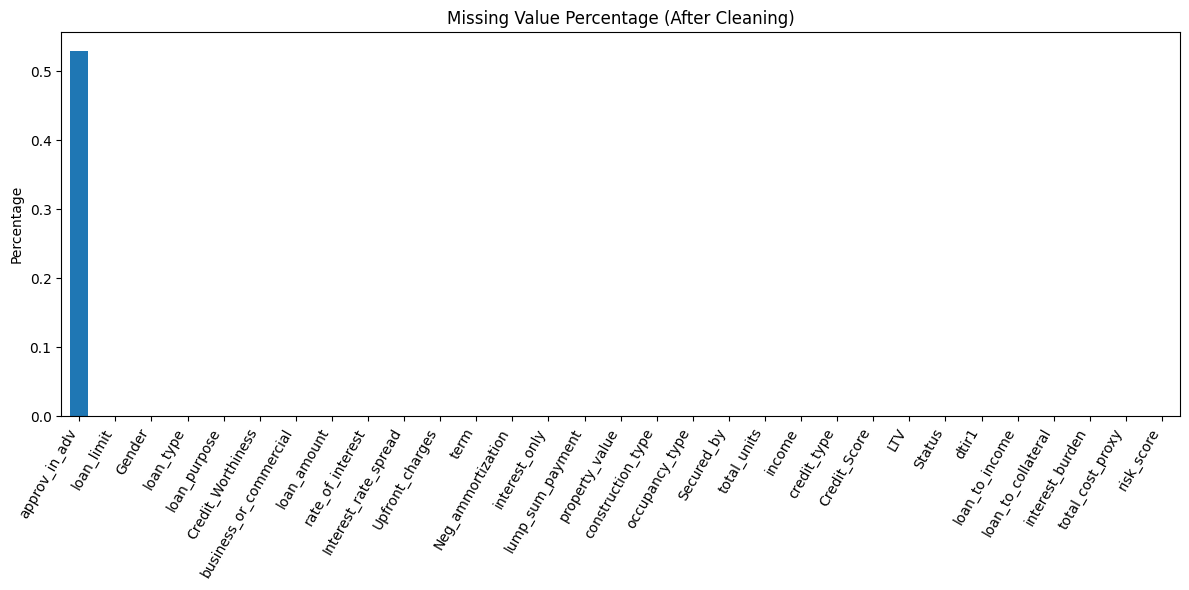

In [55]:
missing_after = (df_model.isnull().sum() / len(df_model)) * 100

plt.figure(figsize=(12,6))
missing_after.sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Value Percentage (After Cleaning)")
plt.ylabel("Percentage")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [54]:
df_model

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,...,credit_type,Credit_Score,LTV,Status,dtir1,loan_to_income,loan_to_collateral,interest_burden,total_cost_proxy,risk_score
0,cf,Sex Not Available,nopre,type1,p1,l1,nob/c,116500,3.990,0.32700,...,EXP,758,98.728814,1,45.0,66.916,0.987,464835.0,467526.13,-16.8
1,cf,Male,nopre,type2,p1,l1,b/c,206500,3.990,0.95605,...,EQUI,552,75.297619,1,40.0,41.458,0.494,823935.0,826626.13,104.8
2,cf,Male,pre,type1,p1,l1,nob/c,406500,4.560,0.20000,...,EXP,834,80.019685,0,46.0,42.875,0.800,1853640.0,1854235.00,-62.0
3,cf,Male,nopre,type1,p4,l1,nob/c,456500,4.250,0.68100,...,EXP,587,69.376900,0,42.0,38.423,0.694,1940125.0,1942816.13,84.6
4,cf,Joint,pre,type1,p1,l1,nob/c,696500,4.000,0.30420,...,CRIF,602,91.886544,0,39.0,66.708,0.919,2786000.0,2786000.00,74.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,cf,Joint,pre,type3,p1,l1,nob/c,236500,4.375,0.53140,...,CIB,533,99.369748,0,44.0,40.214,0.994,1034687.5,1036987.50,117.8
1505,cf,Sex Not Available,nopre,type3,p3,l1,nob/c,196500,3.990,-0.11620,...,EQUI,834,75.297619,1,40.0,72.751,0.470,784035.0,786726.13,-64.4
1506,cf,Male,nopre,type2,p4,l1,b/c,116500,3.990,0.95605,...,EXP,624,73.734177,1,26.0,49.765,0.737,464835.0,467526.13,56.0
1507,cf,Male,nopre,type1,p3,l1,nob/c,136500,3.990,1.01760,...,EXP,840,72.606383,0,38.0,45.485,0.726,544635.0,547745.38,-68.8


In [56]:
df_model.to_csv("cleaned-2.csv")